# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [1]:
from neural_value_helpers import *
from popy.config import COLORS

plt.rcParams.update({'font.size': 8})


---
# Section 1: Get data, extract neural value

In [2]:
monkey, session, subregion = 'ka', '210322', 'MCC'

t_interest_value = [2, 3.5]

neural_dataset = load_data_custom(monkey, session, n_extra_trials=(-1, 1))
neural_dataset = neural_dataset.sel(unit=neural_dataset.subregion==subregion)
neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 16, trial_id: 416, time: 2250)
Coordinates: (12/26)
  * unit              (unit) object 'MCC_06_01' 'MCC_07_01' ... 'MCC_16_01'
    unit_id_original  (unit) int64 26 28 66 33 32 30 35 ... 46 48 49 53 52 61 58
    channel           (unit) int64 6 7 7 8 8 8 9 10 11 12 12 13 13 14 16 16
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '210322' '210322' ... '210322' '210322'
    area              (unit) object 'MCC' 'MCC' 'MCC' ... 'MCC' 'MCC' 'MCC'
    ...                ...
    R_4               (trial_id) float64 0.0 1.0 0.0 0.0 0.0 ... 1.0 0.0 1.0 1.0
    R_5               (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 1.0 0.0 1.0
    R_6               (trial_id) float64 1.0 0.0 0.0 1.0 0.0 ... 0.0 1.0 1.0 0.0
    R_7               (trial_id) float64 0.0 1.0 0.0 0.0 1.0 ... 1.0 0.0 1.0 1.0
    R_8               (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 0.0 1.0 0.0 1.0
    fb_sequence       (trial_id) float64 1.0 0.0 4.0 6.0 7.0 ... 6.0 7.0 3.0 1.0
Data variables:
    firing_rates      (trial_id, unit, time) float64 -0.8091 -0.8091 ... -0.7246
Attributes:
    bin_size:  0.01

## Projection to value subspace

## Define the value subspace

In [3]:
#results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
weights, data_projected = time_resolved_decoder_all_time(neural_dataset, target='R_1')

# get neural value for the current trial and the previous one
data_projected = add_neural_value_coord(data_projected, t_interest=t_interest_value)

#print(f't= {t_interest_fit}, pvalue:', np.round(pvalue, 2))
# save data_projected
#data_projected.to_netcdf(floc)

'''fig, axs = plot_decoder_results(data_projected.decodability, weights, n_extra_trials=(-1, 0))

plt.suptitle(f'{monkey} {subregion} - decoding {target}')
plt.tight_layout()'''

data_projected

<xarray.DataArray (trial_id: 416, time: 2250)>
array([[ 0.08933945,  0.08563893,  0.15291947, ..., -0.24002185,
        -0.3736894 , -0.48798919],
       [ 0.13121569,  0.34608126,  0.66094455, ..., -0.9644075 ,
        -0.78179652, -0.61959681],
       [ 0.04789322,  0.15528952,  0.2737691 , ..., -0.93622808,
        -0.69425426, -0.4436926 ],
       ...,
       [ 0.54265752,  0.47721027,  0.5355515 , ..., -0.28799386,
        -0.48838932, -0.66293024],
       [ 0.53046448,  0.49986963,  0.45749231, ..., -0.66253785,
        -0.64558788, -0.57883597],
       [ 0.11210489,  0.10317157,  0.06935036, ..., -0.38324781,
        -0.39302533, -0.39317052]])
Coordinates: (12/23)
  * trial_id      (trial_id) int64 8 9 10 11 12 13 ... 418 419 420 421 422 423
    block_id      (trial_id) int64 0 0 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9 9 9
    best_target   (trial_id) int64 1 1 1 1 1 1 1 1 1 1 1 ... 3 3 3 3 3 3 3 3 3 3
    target        (trial_id) float64 3.0 1.0 1.0 1.0 1.0 ... 3.0 3.0 3.0 3.0 3.0
    feedback      (trial_id) float64 0.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 0.0 0.0 0.0
    stay_value    (trial_id) float64 0.1671 0.06983 0.4795 ... 0.5253 0.3101
    ...            ...
  * time          (time) float64 -7.5 -7.49 -7.48 -7.47 ... 14.97 14.98 14.99
    epoch         (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 5.0 5.0 5.0 5.0 5.0
    decodability  (time) float64 0.4425 0.469 0.4714 ... 0.5334 0.5407 0.5454
    V_t           (trial_id) float64 -0.07477 -0.6891 ... 0.06282 -0.7216
    V_t_p1        (trial_id) float64 -0.6891 0.04471 -0.02336 ... -0.7216 nan
    dV            (trial_id) float64 -0.6143 0.7338 -0.06806 ... -0.7844 nan

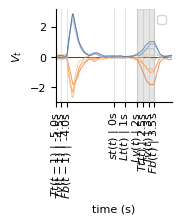

In [4]:
fig, ax = plot_projected_data(data_projected, t_interest_value, n_extra_trials=(-1, 0), xlim=None, paper_format=True)
ax.set_xlim([-5, 5])
# hide legend
ax.legend([])
#plt.suptitle(f'{monkey} {subregion}, t_eval = {t_interest_value}s')

# save figure
fig.savefig(f'figs/{monkey}_{session}_{subregion}_neural_value.svg', bbox_inches='tight', transparent=True)

## Extract neural value

In [5]:
behav_new = data_projected.mean('time').coords.to_dataset().to_dataframe().reset_index()

behav_new['monkey'] = monkey
behav_new['session'] = session
#behav_new['area'] = neural_dataset.area
behav_new['subregion'] = subregion

behav_new = behav_new.dropna()
behav_new


,trial_id,block_id,best_target,target,feedback,stay_value,V0,stay_proba,R_1,R_2,...,R_6,R_7,R_8,fb_sequence,V_t,V_t_p1,dV,monkey,session,subregion
0,8,0,1,3.0,0.0,0.167107,0.118275,0.627026,0.0,0.0,...,1.0,0.0,0.0,1.0,-0.074774,-0.689081,-0.614307,ka,210322,MCC
1,9,0,1,1.0,1.0,0.069825,0.118275,0.373927,0.0,0.0,...,0.0,1.0,0.0,0.0,-0.689081,0.044707,0.733788,ka,210322,MCC
2,10,0,1,1.0,1.0,0.479459,0.118275,0.979006,1.0,0.0,...,0.0,0.0,1.0,4.0,0.044707,-0.023357,-0.068063,ka,210322,MCC
3,11,0,1,1.0,1.0,0.692690,0.118275,0.997786,1.0,1.0,...,1.0,0.0,0.0,6.0,-0.023357,0.981562,1.004919,ka,210322,MCC
4,12,0,1,1.0,1.0,0.818575,0.118275,0.999419,1.0,1.0,...,0.0,1.0,0.0,7.0,0.981562,1.374195,0.392633,ka,210322,MCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,418,9,3,3.0,1.0,0.464248,0.118275,0.975409,0.0,1.0,...,0.0,1.0,0.0,3.0,-0.344059,0.521721,0.865780,ka,210322,MCC
411,419,9,3,3.0,1.0,0.683710,0.118275,0.997564,1.0,0.0,...,1.0,0.0,1.0,5.0,0.521721,0.044813,-0.476907,ka,210322,MCC
412,420,9,3,3.0,1.0,0.813273,0.118275,0.999385,1.0,1.0,...,0.0,1.0,0.0,6.0,0.044813,0.019422,-0.025391,ka,210322,MCC
413,421,9,3,3.0,0.0,0.889763,0.118275,0.999727,1.0,1.0,...,1.0,0.0,1.0,7.0,0.019422,0.062815,0.043393,ka,210322,MCC


---
# Section 2: Analysis of the neural value representation

In [17]:
behav_new = pd.read_pickle(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', 'behav_neural_value_copy', 'behav.pkl'))
#behav_new = behav_new.loc[behav_new.subregion=='dLPFC']
behav_new

,trial_id,block_id,best_target,target,feedback,stay_value,V0,stay_proba,R_1,R_2,...,R_6,R_7,R_8,fb_sequence,V_t,V_t_p1,dV,monkey,session,subregion
0,8,0,3,1.0,0.0,0.576741,0.118275,0.992439,1.0,0.0,...,0.0,1.0,1.0,5.0,-0.064375,-0.036541,0.027834,ka,230520,MCC
1,9,0,3,1.0,1.0,0.340488,0.118275,0.914034,0.0,1.0,...,1.0,0.0,1.0,2.0,-0.093157,-0.034619,0.058538,ka,230520,MCC
2,10,0,3,1.0,0.0,0.610646,0.118275,0.994716,1.0,0.0,...,0.0,1.0,0.0,5.0,0.054733,-0.042339,-0.097072,ka,230520,MCC
3,11,0,3,1.0,1.0,0.360505,0.118275,0.929357,0.0,1.0,...,1.0,0.0,1.0,2.0,-0.050361,-0.014733,0.035628,ka,230520,MCC
4,12,0,3,1.0,0.0,0.622464,0.118275,0.995338,1.0,0.0,...,0.0,1.0,0.0,5.0,-0.060436,0.013611,0.074047,ka,230520,MCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61613,333,7,2,1.0,1.0,0.071378,0.183980,0.313197,0.0,0.0,...,1.0,0.0,0.0,0.0,0.290196,-0.003697,-0.293893,po,140622,dLPFC
61614,334,7,2,1.0,0.0,0.353492,0.183980,0.765319,1.0,0.0,...,0.0,1.0,0.0,4.0,-0.063626,-0.335623,-0.271997,po,140622,dLPFC
61615,335,7,2,1.0,1.0,0.246102,0.183980,0.606636,0.0,1.0,...,0.0,0.0,1.0,2.0,-0.366154,-0.125571,0.240584,po,140622,dLPFC
61616,336,7,2,1.0,1.0,0.475135,0.183980,0.883945,1.0,0.0,...,0.0,0.0,0.0,5.0,0.370116,-0.359816,-0.729932,po,140622,dLPFC


## History in the subspace

### Short history

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection

def raincloud_plot(df, x, y, hue, palette, ax, show_datapoints=True, 
                point_size=3, point_alpha=0.5, violin_alpha=0.6, 
                box_width=0.2, point_offset=0.3):
    """
    Create a raincloud plot combining violin plot, boxplot, and strip plot
    """
    
    # Get unique categories and sort them
    categories = df[x].unique()
    if hasattr(df[x], 'cat') and df[x].cat.ordered:
        categories = df[x].cat.categories
    else:
        categories = sorted(categories)
    
    # Create violin plot (the "cloud")
    violin_parts = ax.violinplot([df[df[x] == cat][y].dropna() for cat in categories], 
                                positions=range(len(categories)), 
                                showmeans=False, showmedians=False, showextrema=False)
    
    # Style the violin plots
    for i, pc in enumerate(violin_parts['bodies']):
        color = palette[i % len(palette)]
        pc.set_facecolor(color)
        pc.set_alpha(violin_alpha)
        pc.set_edgecolor('white')
        pc.set_linewidth(0.5)
        
        # Make violin plot half-width (only show right side)
        # Get the violin path and modify it to only show the right half
        verts = pc.get_paths()[0].vertices
        verts_right = verts.copy()
        verts_right[:, 0] = np.clip(verts_right[:, 0], i, i + 0.5)
        pc.get_paths()[0].vertices = verts_right
    
    # Add box plots (offset to the left)
    box_positions = np.arange(len(categories)) - box_width/2
    box_parts = ax.boxplot([df[df[x] == cat][y].dropna() for cat in categories],
                        positions=box_positions,
                        widths=box_width,
                        patch_artist=True,
                        showfliers=False,
                        boxprops={'linewidth': 0.5, 'alpha': 0.8},
                        medianprops={'linewidth': 1.5, 'color': 'white'},
                        whiskerprops={'linewidth': 1, 'alpha': 0.8},
                        capprops={'linewidth': 1, 'alpha': 0.8})
    
    # Color the box plots
    for i, patch in enumerate(box_parts['boxes']):
        patch.set_facecolor(palette[i % len(palette)])
        patch.set_alpha(0.8)
    
    # Add strip plot (the "rain")
    if show_datapoints:
        for i, cat in enumerate(categories):
            cat_data = df[df[x] == cat][y].dropna()
            if len(cat_data) > 0:
                # Add some jitter to x-positions and offset them
                x_jittered = np.random.normal(i - point_offset, 0.04, len(cat_data))
                ax.scatter(x_jittered, cat_data, 
                        s=point_size**2, alpha=point_alpha, 
                        color='black', edgecolors='none')
    
    # Customize the plot
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    
    return ax

def create_r_style_plot(ax, data, x_col, y_col, palette, title=None):
    """Create R-style plot with violin, box, and jittered points"""
    
    # Get unique categories
    # sort by x_col
    data = data.copy().sort_values(by=x_col)
    categories = data[x_col].unique()
    x_positions = np.arange(len(categories))
    
    # Create violin plots (distributions) - slightly offset to the right
    violin_parts = ax.violinplot([data.loc[data[x_col] == cat, y_col].values for cat in categories], 
                                positions=x_positions + 0.15, widths=0.3, showmeans=False, 
                                showmedians=False, showextrema=False)
    
    # Color the violin plots
    colors = [palette[cat] for cat in categories]
    for pc, color in zip(violin_parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.3)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)
    
    # Create boxplots - centered
    box_data = [data.loc[data[x_col] == cat, y_col].values for cat in categories]
    bp = ax.boxplot(box_data, positions=x_positions, widths=0.2, patch_artist=True,
                   boxprops=dict(alpha=0.7, linewidth=1.5),
                   showfliers=True,
                   medianprops=dict(color='black', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='black', markersize=3, alpha=0.5))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Add jittered points - slightly offset to the left
    for i, cat in enumerate(categories):
        y_data = data.loc[data[x_col] == cat, y_col].values
        x_jitter = np.random.normal(x_positions[i] - 0.15, 0.04, size=len(y_data))
        ax.scatter(x_jitter, y_data, alpha=0.6, s=20, 
                  color=colors[i], edgecolor='black', linewidth=0.5)
    
    # Perform t-test and add significance
    if len(categories) == 2:
        group1_data = data.loc[data[x_col] == categories[0], y_col]
        group2_data = data.loc[data[x_col] == categories[1], y_col]
        #_, p_value = stats.ttest_ind(group1_data, group2_data)
        _, p_value = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

        
        # Position for significance bar
        y_max = data[y_col].max()
        y_pos = y_max + 0.1 * abs(y_max)
        
        # Add significance annotation
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'n.s.'
        
        # Add the bar and text for p-value
        ax.plot([0, 1], [y_pos, y_pos], '-k', lw=1.5)
        ax.text(0.5, y_pos + 0.02 * abs(y_max), f'p = {p_value:.3f} {significance}, n={len(group1_data)}', 
                ha='center', va='bottom', fontsize=10)
    
    # Formatting
    ax.axhline(0, linestyle='--', alpha=0.7, color='black')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Unrewarded', 'Rewarded'])
    ax.set_ylabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$')
    ax.set_xlabel('')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return ax


def projection_timepoint(behav_new, paper_format=False, ylim=None, show_datapoints=True):
    # project to axis
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        h = 1.2  # in cm
        w = 2
        s = 5
    else:
        plt.rcParams.update({'font.size': 18})
        h = 3  # in cm
        w = 6  # in cm
        s = 10

    # Example: get 10 colors from your scale
    colors = sample_colors(8)
        
    df = pd.DataFrame({
        'trial_id': behav_new.trial_id.values,
        'V_t': behav_new.V_t.values,
        #'V_t_p1': data_projected.V_t_p1.values,
        'dV': behav_new.dV.values,
        'feedback': behav_new.feedback.values,
        'fb_sequence': behav_new.fb_sequence.values,
        'fb_sequence_last_2': behav_new.fb_sequence.values % 4,
    })

    label_mapping_long = {0: '0\n0\n0', 1: '0\n0\n1', 2:'0\n1\n0', 3:'0\n1\n1', 4: '1\n0\n0', 5: '1\n0\n1', 6:'1\n1\n0', 7:'1\n1\n1'}
    label_mapping_short = {0: '0\n0', 1: '0\n1', 2:'1\n0', 3:'1\n1'}
    df['fb_sequence'] = df['fb_sequence'].map(label_mapping_long)
    df['fb_sequence_last_2'] = df['fb_sequence_last_2'].map(label_mapping_short)

    print(df)

    # distribution of pos and neg feedback along neural value
    fig, axs = plt.subplots(1, 2, figsize=(2*w, h), gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.1}) 

    # First subplot: boxplot (unchanged)
    ax = axs[0]

    sns.boxplot(df.sort_values('fb_sequence'), x='fb_sequence', y='V_t', palette=colors, ax=ax, showfliers=True, boxprops={'linewidth': 0.5})
    if show_datapoints:
        sns.stripplot(df.sort_values('fb_sequence'), x='fb_sequence', y='V_t', color='black', size=3, alpha=0.5, ax=ax)
    ax.axhline(0, color='k', linestyle='--', alpha=0.7, linewidth=0.75, zorder=0)

    # second subplot
    ax = axs[1]

    # Usage example (replace your existing code with this):
    """raincloud_plot(df.sort_values('feedback'), x='feedback', y='dV', 
                hue='feedback', palette=COLORS, ax=ax, show_datapoints=show_datapoints)"""

    create_r_style_plot(ax, df, 'feedback', 'dV', COLORS)

    # Add the horizontal line at y=0
    ax.axhline(0, color='k', linestyle='--', alpha=0.7, linewidth=0.75, zorder=0)

    ax = axs[0]
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
    #ax.set_xlabel('Feedback sequence')
    ax.set_ylabel('$V_t$')
    #ax.set_yticks([0, .5, 1])   
    #ax.set_yticklabels([0, .5, 1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax = axs[1]
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
    #ax.set_xlabel('Feedback sequence')
    ax.set_ylabel('$\Delta V$')
    '''ax.set_yticks([0, 1, 2, 3])   
    ax.set_yticklabels('''
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    #plt.tight_layout()
    return fig, ax



       trial_id       V_t        dV  feedback fb_sequence fb_sequence_last_2
0             8 -0.064375  0.027834       0.0     1\n0\n1               0\n1
1             9 -0.093157  0.058538       1.0     0\n1\n0               1\n0
2            10  0.054733 -0.097072       0.0     1\n0\n1               0\n1
3            11 -0.050361  0.035628       1.0     0\n1\n0               1\n0
4            12 -0.060436  0.074047       0.0     1\n0\n1               0\n1
...         ...       ...       ...       ...         ...                ...
61613       333  0.290196 -0.293893       1.0     0\n0\n0               0\n0
61614       334 -0.063626 -0.271997       0.0     1\n0\n0               0\n0
61615       335 -0.366154  0.240584       1.0     0\n1\n0               1\n0
61616       336  0.370116 -0.729932       1.0     1\n0\n1               0\n1
61617       337  0.129315 -0.029102       1.0     1\n1\n0               1\n0

[61618 rows x 6 columns]


/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_41684/138093096.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df.sort_values('fb_sequence'), x='fb_sequence', y='V_t', palette=colors, ax=ax, showfliers=True, boxprops={'linewidth': 0.5})
/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_41684/138093096.py:216: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_41684/138093096.py:228: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upp

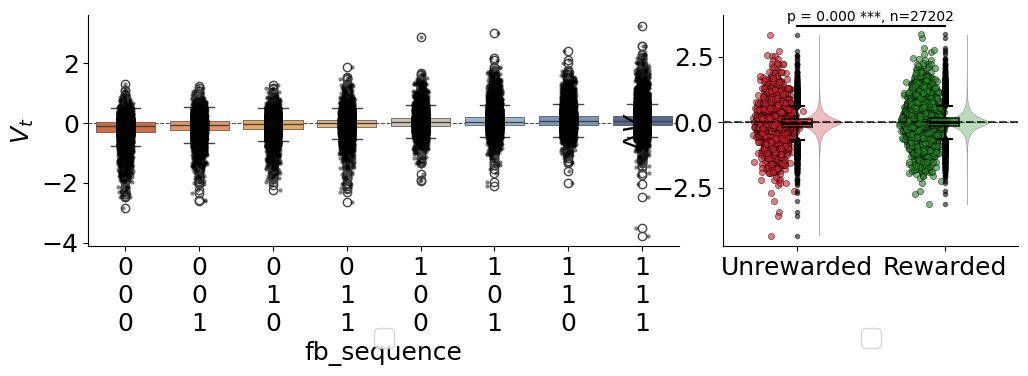

In [19]:
fig, ax = projection_timepoint(behav_new, paper_format=False, ylim=None, show_datapoints=True)
#plt.suptitle(f'{monkey} {subregion}, t_fit = {t_interest_value} s')

# save figure
fig.savefig(f'figs/{monkey}_{session}_{subregion}_neural_value_projection.svg', bbox_inches='tight', transparent=True)

### Long history regression: Simple GLM

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# Data setup
weights_all = []
for monkey in behav_new.monkey.unique():
    for subregion in behav_new.subregion.unique():
        behav_temp = behav_new.loc[(behav_new.monkey == monkey) & (behav_new.subregion == subregion)]

        for session in behav_temp.session.unique():
            behav = behav_temp.loc[behav_temp.session == session].copy()

            y = behav.V_t.values
            X = np.array([behav[f'R_{i}'].values for i in range(1, 9)]).T
            # add one more column for the randomly shuffled values
            random_col = behav[f'R_{8}'].values
            random_col = np.random.permutation(random_col)
            X = np.column_stack((X, random_col))

            # Add intercept for statsmodels
            X_sm = sm.add_constant(X)
            model = sm.OLS(y, X_sm)
            results = model.fit()

            # Extract weights and p-values (skip intercept)
            weights = results.params[1:]
            pvals = results.pvalues[1:]
            
            res_temp = {f'R_{i}': results.params[i] for i in range(1, len(weights))}
            res_temp['random'] = results.params[-1]
            res_temp['monkey'] = monkey
            res_temp['session'] = session
            res_temp['subregion'] = subregion
            weights_all.append(res_temp)

weights_all = pd.DataFrame(weights_all)
weights_all



,R_1,R_2,R_3,R_4,R_5,R_6,R_7,R_8,random,monkey,session,subregion
0,0.005354,0.006369,0.003400,0.004678,0.014219,-0.009984,-0.001783,0.003134,-0.006440,ka,230520,MCC
1,0.034934,-0.002829,0.009272,0.021281,0.039056,-0.020483,0.016412,0.008823,-0.010247,ka,230720,MCC
2,0.015608,0.023791,0.023867,-0.018627,-0.018780,0.006376,0.005032,-0.001163,0.009388,ka,160620,MCC
3,0.052029,0.009590,-0.007915,-0.008947,-0.026162,0.011018,0.011690,-0.006414,-0.008593,ka,080620,MCC
4,0.251002,0.060843,0.110908,0.004400,-0.002032,-0.020259,0.006117,0.046917,0.018427,ka,150720,MCC
...,...,...,...,...,...,...,...,...,...,...,...,...
189,0.321416,-0.007458,-0.012592,0.008541,0.086583,0.031841,-0.041140,0.034951,-0.002351,po,090322,vLPFC
190,0.834837,0.205281,0.050031,0.052815,0.004419,0.001070,0.158588,0.101565,0.087446,po,180322,vLPFC
191,0.814074,0.217142,0.176546,0.061334,0.150746,0.157844,0.145913,0.062238,-0.016136,po,040322,vLPFC
192,-0.018507,0.044143,0.047453,0.104598,0.000914,0.085974,0.040779,0.076501,-0.053120,po,220422,vLPFC


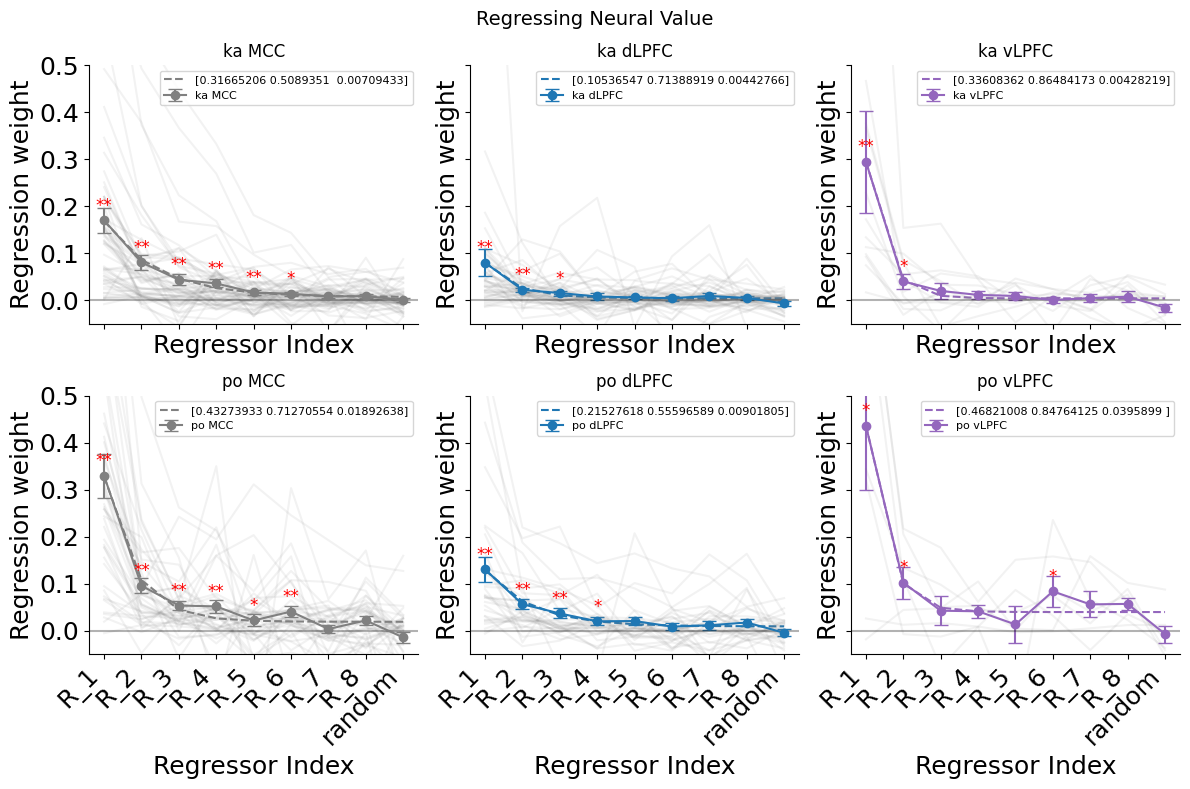

In [21]:


fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
# font size
plt.rcParams.update({'font.size': 10})

for m, monkey in enumerate(behav_new.monkey.unique()):
    for s, subregion in enumerate(behav_new.subregion.unique()):
        ax = axs[m, s]

        weights_temp = weights_all.loc[(weights_all.monkey == monkey) & (weights_all.subregion == subregion)]
        weights_temp = weights_temp.drop(columns=['monkey', 'session', 'subregion'])

        # Visualization - mean weights with error bars and in the background plot individual sessions with lines connecting them
        # weights temp is a DataFrame with weights for each regressor
        weights = weights_temp.mean().values
        weights_err = weights_temp.std().values / np.sqrt(len(weights_temp))
        ax.errorbar(range(1, len(weights) + 1), weights, yerr=weights_err, fmt='o', 
                    label=f'{monkey} {subregion}', color=COLORS[subregion], linestyle='-',
                    alpha=1, capsize=5, zorder=2)
        
        # fit exponential and print params
        def exponential_fit(x, C, a, b):
            return C*(a * (1-a) ** (x - 1)) + b
        from scipy.optimize import curve_fit
        x_data = np.arange(1, len(weights) + 1)
        popt, _ = curve_fit(exponential_fit, x_data, weights, p0=(1, 0.5, 0))
        fit_line = exponential_fit(x_data, *popt)
        ax.plot(x_data, fit_line, color=COLORS[subregion], linestyle='--', label=f'{popt}', zorder=1)


        # Plot individual session weights
        for i, row in weights_temp.iterrows():
            ax.plot(range(1, len(weights) + 1), row.values, color='grey', alpha=0.1)

        # see if the weights are significantly different from reference (R_8)
        reference_weight = weights_temp['random'].values
        for i in range(1, len(weights) - 1):
            _, pval = stats.mannwhitneyu(weights_temp[f'R_{i}'].values, reference_weight, alternative='two-sided')
            if pval < 0.05 and pval >= 0.01:
                ax.text(i, weights[i-1] + 0.02, '*', color='red', fontsize=12, ha='center')
            elif pval < 0.01:
                ax.text(i, weights[i-1] + 0.02, '**', color='red', fontsize=12, ha='center')
            elif pval < 0.001:
                ax.text(i, weights[i-1] + 0.02, '***', color='red', fontsize=12, ha='center')
            
        # Plot the weights as a bar plot

        
        #ax.scatter(range(1, len(weights) + 1), weights, color='steelblue', alpha=0.7, s=80, edgecolor='k')
        ax.axhline(0, color='black', linestyle='-', alpha=0.3)
        ax.set_xlabel('Regressor Index')
        ax.set_ylabel('Regression weight')
        ax.set_xticks(range(1, len(weights) + 1))
        ax.set_xticklabels([f'R_{i}' for i in range(1, len(weights))] + ['random'], rotation=45, ha='right')
        #ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)
        sns.despine()

        ax.set_ylim(-0.05, 0.5)

        ax.set_title(f'{monkey} {subregion}')

plt.suptitle('Regressing Neural Value', fontsize=14)
plt.tight_layout()

### Long history regression: CPD

In [22]:
n_perms = 1000
cpd_all = []

for monkey in behav_new.monkey.unique():
    for subregion in behav_new.subregion.unique():
        behav_temp = behav_new.loc[(behav_new.monkey == monkey) & (behav_new.subregion == subregion)]

        for session in behav_temp.session.unique():
            behav = behav_temp.loc[behav_temp.session == session].copy()

            y = behav.V_t.values
            X_full = np.array([behav[f'R_{i}'].values for i in range(1, 9)]).T
            random_col = np.random.permutation(behav['R_8'].values)
            X_full = np.column_stack((X_full, random_col))

            X_full_sm = sm.add_constant(X_full)
            model_full = sm.OLS(y, X_full_sm).fit()
            r2_full = model_full.rsquared

            cpd_temp = {}
            pvals_temp = {}

            for i in range(X_full.shape[1]):
                # Leave out regressor i
                X_reduced = np.delete(X_full, i, axis=1)
                X_reduced_sm = sm.add_constant(X_reduced)
                model_reduced = sm.OLS(y, X_reduced_sm).fit()
                r2_reduced = model_reduced.rsquared
                # Calculate change in explained variance, in percentage points
                cpd_actual = ((r2_full - r2_reduced) / r2_full) * 100

                # Permutation test
                cpd_perm = []
                for _ in range(n_perms):
                    X_perm = X_full.copy()
                    X_perm[:, i] = np.random.permutation(X_perm[:, i])

                    X_perm_sm = sm.add_constant(X_perm)
                    model_perm_full = sm.OLS(y, X_perm_sm).fit()
                    r2_perm_full = model_perm_full.rsquared

                    X_perm_reduced = np.delete(X_perm, i, axis=1)
                    X_perm_reduced_sm = sm.add_constant(X_perm_reduced)
                    model_perm_reduced = sm.OLS(y, X_perm_reduced_sm).fit()
                    r2_perm_reduced = model_perm_reduced.rsquared

                    cpd_perm.append(((r2_perm_full - r2_perm_reduced) / r2_perm_full) * 100)

                cpd_perm = np.array(cpd_perm)
                pval = (np.sum(cpd_perm >= cpd_actual) + 1) / (n_perms + 1)

                key = f'R_{i+1}' if i < 8 else 'random'
                cpd_temp[key] = cpd_actual
                pvals_temp[f'pval_{key}'] = pval

            cpd_temp.update(pvals_temp)
            cpd_temp['monkey'] = monkey
            cpd_temp['session'] = session
            cpd_temp['subregion'] = subregion
            cpd_all.append(cpd_temp)

cpd_all = pd.DataFrame(cpd_all)
cpd_all

,R_1,R_2,R_3,R_4,R_5,R_6,R_7,R_8,random,pval_R_1,...,pval_R_3,pval_R_4,pval_R_5,pval_R_6,pval_R_7,pval_R_8,pval_random,monkey,session,subregion
0,5.161194,9.382384,1.796210,5.783333,40.972940,18.679739,0.394419,1.769313,15.603300,0.537463,...,0.742258,0.532468,0.088911,0.247752,0.864136,0.746254,0.299700,ka,230520,MCC
1,24.518089,0.188834,1.567335,9.810706,31.140714,7.327629,5.795450,1.775527,2.391034,0.104895,...,0.663337,0.276723,0.050949,0.369630,0.413586,0.659341,0.599401,ka,230720,MCC
2,10.824924,25.656112,26.780865,16.558304,15.861556,1.543588,1.639782,0.145829,0.217354,0.179820,...,0.032967,0.080919,0.096903,0.623377,0.589411,0.875125,0.836164,ka,160620,MCC
3,72.573757,2.449239,1.716998,2.292603,16.528609,2.714200,3.558950,0.939480,0.205420,0.001998,...,0.544456,0.515485,0.076923,0.477522,0.362637,0.684316,0.821179,ka,080620,MCC
4,61.501604,3.686686,11.618375,0.012206,0.003356,0.351464,0.053594,1.911534,0.124654,0.000999,...,0.000999,0.915085,0.961039,0.511489,0.794206,0.128871,0.709291,ka,150720,MCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,84.420790,0.104869,0.010405,0.003621,5.835176,0.531896,1.530485,0.846735,2.490294,0.000999,...,0.950050,0.975025,0.124875,0.644356,0.418581,0.555445,0.302697,po,090322,vLPFC
190,79.539155,4.479319,0.640167,0.464799,0.017463,0.006812,3.404649,1.544317,1.717665,0.000999,...,0.414585,0.512488,0.902098,0.924076,0.060939,0.205794,0.163836,po,180322,vLPFC
191,61.593435,4.468426,2.734446,0.336620,2.130762,2.332937,1.967104,0.350998,0.027128,0.000999,...,0.006993,0.333666,0.027972,0.019980,0.027972,0.369630,0.814186,po,040322,vLPFC
192,0.075549,7.263554,1.494248,22.460077,0.118545,9.765546,3.532019,18.190590,11.616948,0.949051,...,0.756244,0.227772,0.932068,0.416583,0.631369,0.255744,0.368631,po,220422,vLPFC


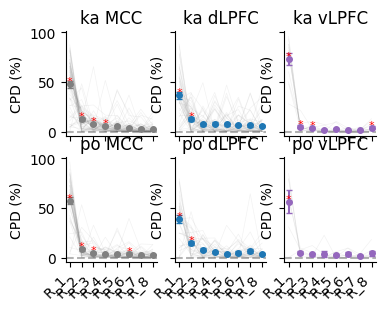

In [23]:
fig, axs = plt.subplots(2, 3, figsize=(4, 3), sharex=True, sharey=True)

cpd_cols = [col for col in cpd_all.columns if col.startswith('R_') or col == 'random']
cpd_means = cpd_all[cpd_cols].mean().values
ax.set_ylim(-0.01, max(0.05, np.max(cpd_means)+0.01))

for m, monkey in enumerate(behav_new.monkey.unique()):
    for s, subregion in enumerate(behav_new.subregion.unique()):
        ax = axs[m, s]

        cpd_temp = cpd_all.loc[(cpd_all.monkey == monkey) & (cpd_all.subregion == subregion)]

        cpd_cols = [col for col in cpd_temp.columns if col.startswith('R_')]
        cpd_vals = cpd_temp[cpd_cols]
        random_vals = cpd_temp['random']

        cpd_means = cpd_vals.mean().values
        cpd_sems = cpd_vals.std().values / np.sqrt(len(cpd_vals))

        # Plot means + error bars
        ax.errorbar(range(1, len(cpd_means)+1), cpd_means, yerr=cpd_sems, fmt='o',
                    color=COLORS[subregion], label='session mean ± SEM', markersize=4, capsize=2, zorder=3)
        

        # Plot individual sessions
        for _, row in cpd_vals.iterrows():
            ax.plot(range(1, len(cpd_means)+1), row.values, color='grey', alpha=0.1
                    , linewidth=0.5, zorder=1)
            

        # Stars: compare each regressor to 'random'
        for i, reg in enumerate(cpd_cols):
            test_vals = cpd_vals[reg].values
            _, pval = stats.mannwhitneyu(test_vals, random_vals.values, alternative='greater')
            if pval < 0.05:
                ax.text(i+1, cpd_means[i] + 0.002, '*', color='red', fontsize=8, ha='center')
            '''elif pval < 0.01:
                ax.text(i+1, cpd_means[i] + 0.002, '**', color='red', fontsize=8, ha='center')
            elif pval < 0.05:
                ax.text(i+1, cpd_means[i] + 0.002, '*', color='red', fontsize=8, ha='center')'''

        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax.set_title(f'{monkey} {subregion}')
        ax.set_ylabel('CPD (%)')
        ax.set_xticks(range(1, len(cpd_cols)+1))
        ax.set_xticklabels(cpd_cols, rotation=45, ha='right')
        sns.despine()
        #ax.legend(loc='upper right', fontsize=8)

#plt.tight_layout()

# save svg
plt.savefig(f'figs/cpds_{monkey}_{subregion}.svg', format='svg', bbox_inches='tight')


In [24]:
from collections import defaultdict

# Initialize container
sig_counts = []

for monkey in behav_new.monkey.unique():
    for subregion in behav_new.subregion.unique():
        cpd_temp = cpd_all[(cpd_all.monkey == monkey) & (cpd_all.subregion == subregion)]
        n_sessions = cpd_temp.shape[0]
        
        row = {'monkey': monkey, 'subregion': subregion}
        for reg in [col for col in cpd_temp.columns if col.startswith('R_') or col == 'random']:
            count = (cpd_temp[f'pval_{reg}'] < 0.05).sum()
            row[reg] = count
        sig_counts.append(row)

sig_counts_df = pd.DataFrame(sig_counts)
sig_counts_df

,monkey,subregion,R_1,R_2,R_3,R_4,R_5,R_6,R_7,R_8,random
0,ka,MCC,46,28,20,9,4,3,4,4,3
1,ka,dLPFC,23,7,4,2,2,1,3,2,3
2,ka,vLPFC,12,5,2,0,0,0,0,3,0
3,po,MCC,35,15,4,6,2,5,2,2,1
4,po,dLPFC,20,7,4,2,3,1,0,2,1
5,po,vLPFC,6,3,2,0,1,2,1,1,1


/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_41684/1287633711.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


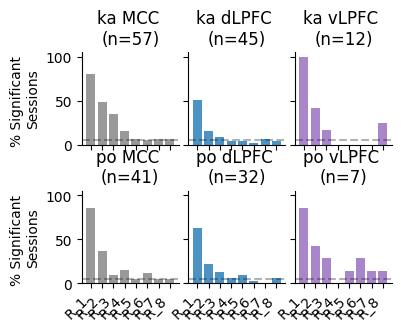

In [25]:
# small gap
fig, axs = plt.subplots(2, 3, figsize=(4, 3), sharex=True, sharey=True, gridspec_kw={'hspace': 0.5, 'wspace': 0.1})

regressors = [col for col in sig_counts_df.columns if col.startswith('R_')]
n_sessions = cpd_all.groupby(['monkey', 'subregion']).size().unstack().fillna(0)

for m, monkey in enumerate(behav_new.monkey.unique()):
    for s, subregion in enumerate(behav_new.subregion.unique()):
        ax = axs[m, s]

        # Get row from sig_counts_df
        temp = sig_counts_df[(sig_counts_df.monkey == monkey) & (sig_counts_df.subregion == subregion)]
        if temp.empty:
            continue
        counts = temp[regressors].values.flatten()
        session_n = int(n_sessions.loc[monkey, subregion])
        props = counts / session_n if session_n > 0 else 0

        ax.bar(range(1, len(regressors)+1), props * 100, color=COLORS[subregion], alpha=0.8)
        ax.set_xticks(range(1, len(regressors)+1))
        ax.set_xticklabels(regressors, rotation=45, ha='right')
        #ax.set_ylim(0, session_n + 1)
        if s == 0:
            ax.set_ylabel('% Significant \nSessions')
        ax.set_title(f'{monkey} {subregion} \n(n={session_n})')
        ax.axhline(y=5, color='black', linestyle='--', alpha=0.3)  # Optional threshold line

        sns.despine()

plt.tight_layout()


# Save the figure
plt.savefig(f'figs/sig_sessions_{monkey}_{subregion}.svg', format='svg', bbox_inches='tight', transparent=True)


## Red-green plot

AttributeError: 'DataFrame' object has no attribute 'V_t_behav'

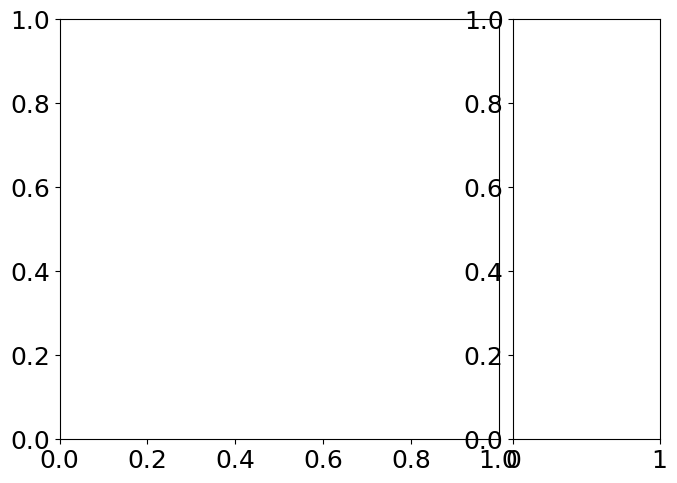

In [26]:
fig, ax = green_red_plot(behav_new, paper_format=False, xlim=None, ylim=None)
#plt.suptitle(f'{monkey} {subregion}, t_fit = {t_interest_value} s')

#fig.savefig(f'figs/green_red_plot_{monkey}_{subregion}.svg', bbox_inches='tight', transparent=True, dpi=300)